In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('exoplanets.csv', comment='#')

# Basic look
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())

# Check missing values
print("\nMissing values:\n", df.isnull().sum().sort_values(ascending=False).head(20))

# Basic stats
print("\nBasic Stats:\n", df.describe())

Shape: (6298, 84)

Columns:
 ['pl_name', 'hostname', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'pl_controv_flag', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2', 'st_masslim', 'st_met', 'st_meterr1', 'st_meterr2', 'st_metlim', 'st_metratio', 'st_logg', 'st_loggerr1', 'st_loggerr2',

In [5]:
# Keep only the useful columns
columns_needed = [
    'pl_name', 'hostname', 'discoverymethod', 'disc_year',
    'pl_orbper', 'pl_rade', 'pl_bmasse', 'pl_eqt',
    'sy_dist', 'sy_snum', 'sy_pnum'
]

df_clean = df[columns_needed].copy()

# Rename columns to readable names
df_clean.columns = [
    'planet_name', 'star_name', 'discovery_method', 'discovery_year',
    'orbital_period_days', 'planet_radius_earth', 'planet_mass_earth', 'equilibrium_temp_k',
    'distance_lightyears', 'num_stars', 'num_planets'
]

# Check missing values
print("Missing values before cleaning:")
print(df_clean.isnull().sum())

# Drop rows where key columns are missing
df_clean = df_clean.dropna(subset=['planet_radius_earth', 'discovery_year'])

# Fill remaining missing with median
df_clean['equilibrium_temp_k'] = df_clean['equilibrium_temp_k'].fillna(df_clean['equilibrium_temp_k'].median())
df_clean['planet_mass_earth'] = df_clean['planet_mass_earth'].fillna(df_clean['planet_mass_earth'].median())
df_clean['orbital_period_days'] = df_clean['orbital_period_days'].fillna(df_clean['orbital_period_days'].median())
df_clean['distance_lightyears'] = df_clean['distance_lightyears'].fillna(df_clean['distance_lightyears'].median())

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

print("\nClean dataset shape:", df_clean.shape)

# Save cleaned data
df_clean.to_csv('exoplanets_clean.csv', index=False)
print("\nSaved as exoplanets_clean.csv ✅")

Missing values before cleaning:
planet_name              0
star_name                0
discovery_method         0
discovery_year           1
orbital_period_days    340
planet_radius_earth     50
planet_mass_earth       31
equilibrium_temp_k     521
distance_lightyears     27
num_stars                0
num_planets              0
dtype: int64

Missing values after cleaning:
planet_name            0
star_name              0
discovery_method       0
discovery_year         0
orbital_period_days    0
planet_radius_earth    0
planet_mass_earth      0
equilibrium_temp_k     0
distance_lightyears    0
num_stars              0
num_planets            0
dtype: int64

Clean dataset shape: (6247, 11)

Saved as exoplanets_clean.csv ✅


In [ ]:
import pymysql
import pandas as pd

# Load clean data
df_clean = pd.read_csv('exoplanets_clean.csv')

# Connect to MySQL
conn = pymysql.connect(
    host='localhost',
    user='root',
    password='your_password',  # 👈 change this
    database='nasa_exoplanets'
)

cursor = conn.cursor()

# Insert data row by row
for _, row in df_clean.iterrows():
    cursor.execute("""
        INSERT INTO exoplanets VALUES (%s,%s,%s,%s,%s,%s,%s,%s,%s,%s,%s)
    """, tuple(row))

conn.commit()
conn.close()
print(f"Inserted {len(df_clean)} rows into MySQL ✅")

Inserted 6247 rows into MySQL ✅


C:\Users\tsaip\AppData\Local\Temp\ipykernel_8048\2821102400.py:27: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\tsaip\AppData\Local\Temp\ipykernel_8048\2821102400.py:28: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) Arial.
  plt.savefig('chart1_discoveries_over_time.png', dpi=150)


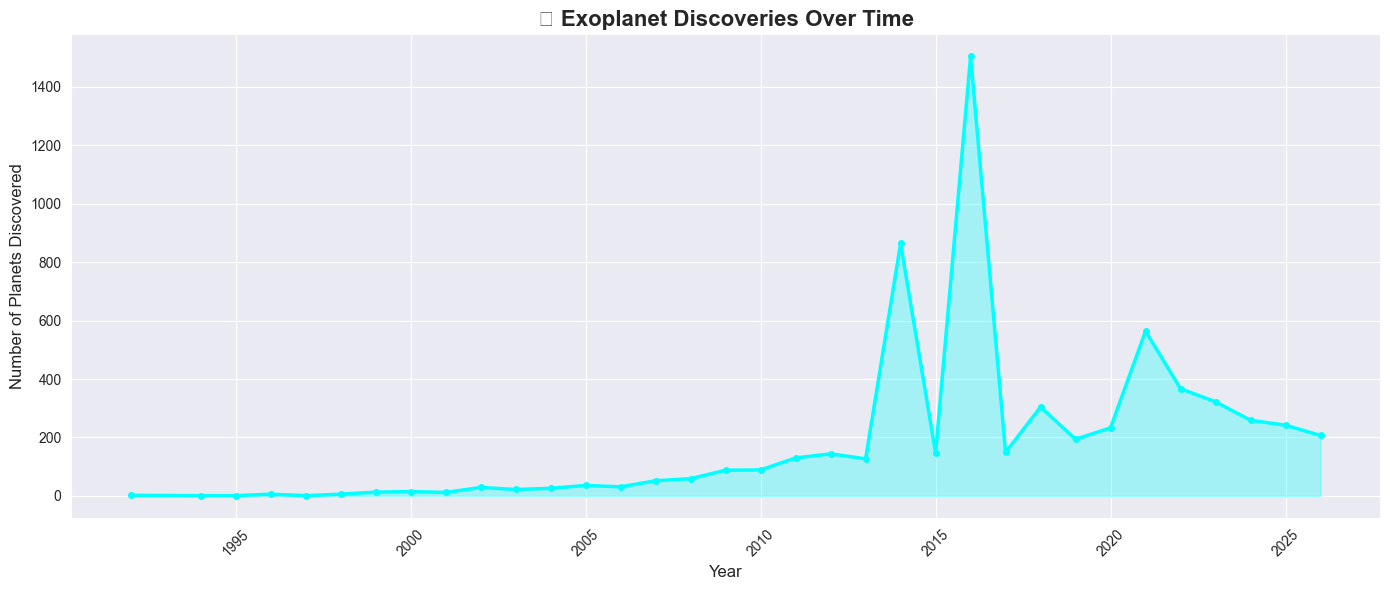

Chart 1 saved


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load clean data
df = pd.read_csv('exoplanets_clean.csv')

# Set style
sns.set_style("darkgrid")
plt.figure(figsize=(14, 6))

# Count planets per year
yearly = df.groupby('discovery_year')['planet_name'].count().reset_index()
yearly.columns = ['year', 'count']

# Plot
plt.plot(yearly['year'], yearly['count'], color='cyan', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(yearly['year'], yearly['count'], alpha=0.3, color='cyan')

# Labels
plt.title('🚀 Exoplanet Discoveries Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Planets Discovered', fontsize=12)
plt.xticks(rotation=45)

# Save
plt.tight_layout()
plt.savefig('chart1_discoveries_over_time.png', dpi=150)
plt.show()
print("Chart 1 saved")

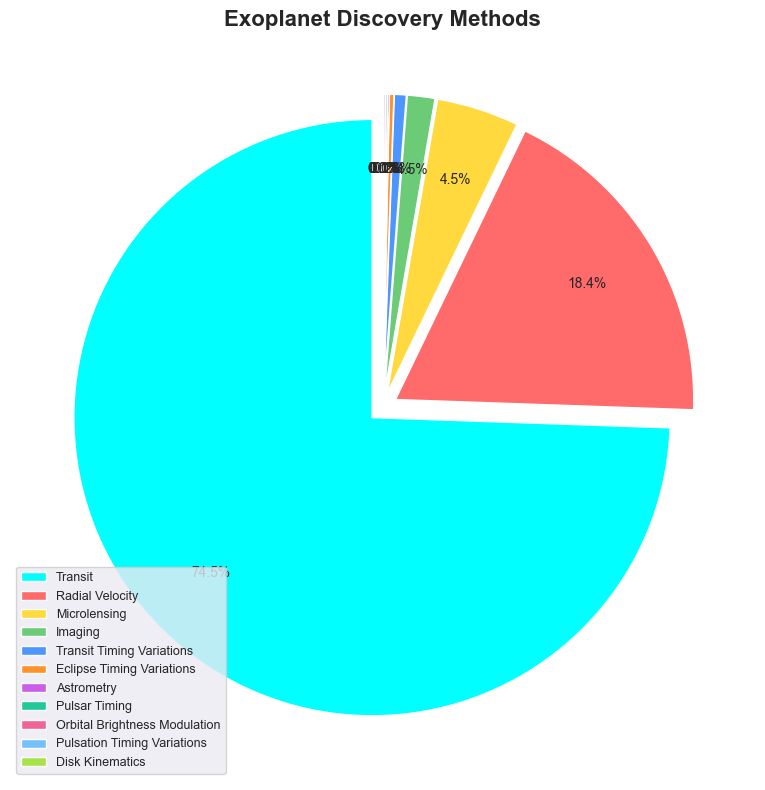

Chart 2 saved ✅


In [4]:
plt.figure(figsize=(12, 8))

methods = df.groupby('discovery_method')['planet_name'].count().sort_values(ascending=False)

colors = ['#00ffff', '#ff6b6b', '#ffd93d', '#6bcb77', '#4d96ff',
          '#ff922b', '#cc5de8', '#20c997', '#f06595', '#74c0fc', '#a9e34b']

# Explode small slices to separate them
explode = [0.05] * len(methods)

plt.pie(methods.values, labels=None, autopct='%1.1f%%',
        colors=colors, startangle=90, pctdistance=0.75, explode=explode)

# Add legend instead of labels
plt.legend(methods.index, loc='lower left', fontsize=9)
plt.title('Exoplanet Discovery Methods', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('chart2_discovery_methods.png', dpi=150)
plt.show()
print("Chart 2 saved ✅")

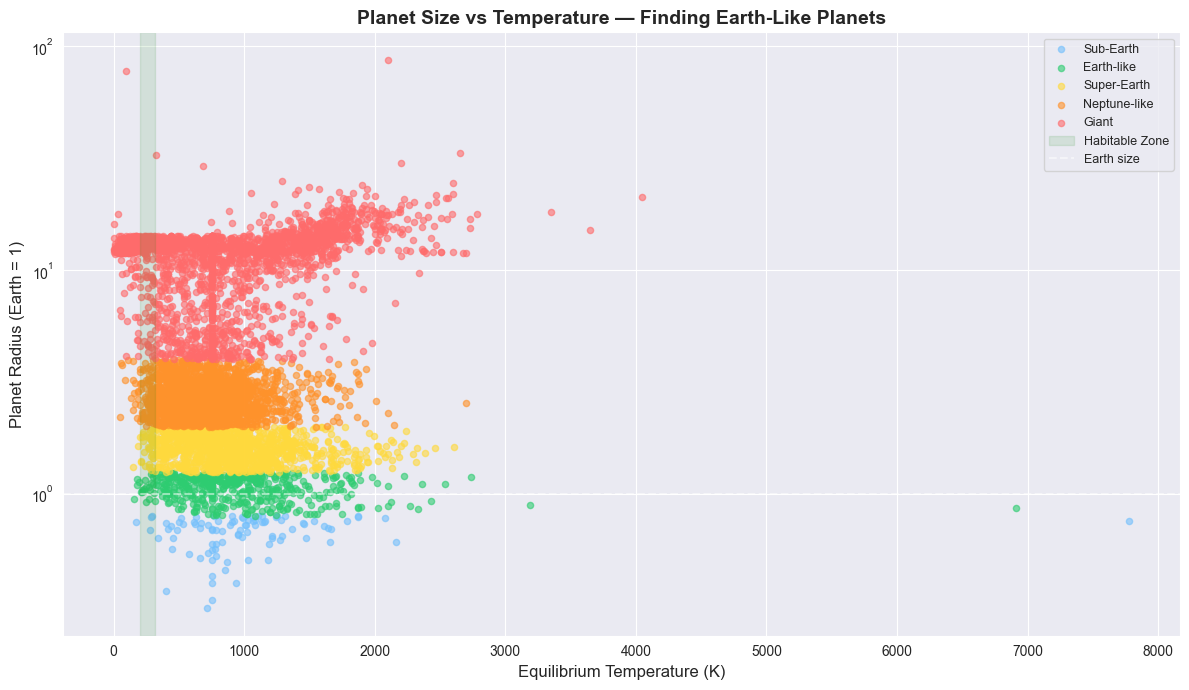

Chart 3 saved ✅


In [5]:
plt.figure(figsize=(12, 7))

# Filter planets with temperature data
scatter_df = df[df['equilibrium_temp_k'] > 0].copy()

# Color by size category
scatter_df['size_category'] = pd.cut(scatter_df['planet_radius_earth'],
                                      bins=[0, 0.8, 1.25, 2, 4, 100],
                                      labels=['Sub-Earth', 'Earth-like', 'Super-Earth', 'Neptune-like', 'Giant'])

colors_map = {
    'Sub-Earth': '#74c0fc',
    'Earth-like': '#2ecc71',
    'Super-Earth': '#ffd93d',
    'Neptune-like': '#ff922b',
    'Giant': '#ff6b6b'
}

for category, color in colors_map.items():
    mask = scatter_df['size_category'] == category
    plt.scatter(scatter_df[mask]['equilibrium_temp_k'],
                scatter_df[mask]['planet_radius_earth'],
                c=color, label=category, alpha=0.6, s=20)

# Earth's habitable zone (roughly 200-320K)
plt.axvspan(200, 320, alpha=0.1, color='green', label='Habitable Zone')
plt.axhline(y=1.0, color='white', linestyle='--', alpha=0.5, label='Earth size')

plt.xlabel('Equilibrium Temperature (K)', fontsize=12)
plt.ylabel('Planet Radius (Earth = 1)', fontsize=12)
plt.title('Planet Size vs Temperature — Finding Earth-Like Planets', fontsize=14, fontweight='bold')
plt.legend(fontsize=9)
plt.yscale('log')

plt.tight_layout()
plt.savefig('chart3_earthlike_planets.png', dpi=150)
plt.show()
print("Chart 3 saved ✅")

Total Earth-like planets in habitable zone: 18


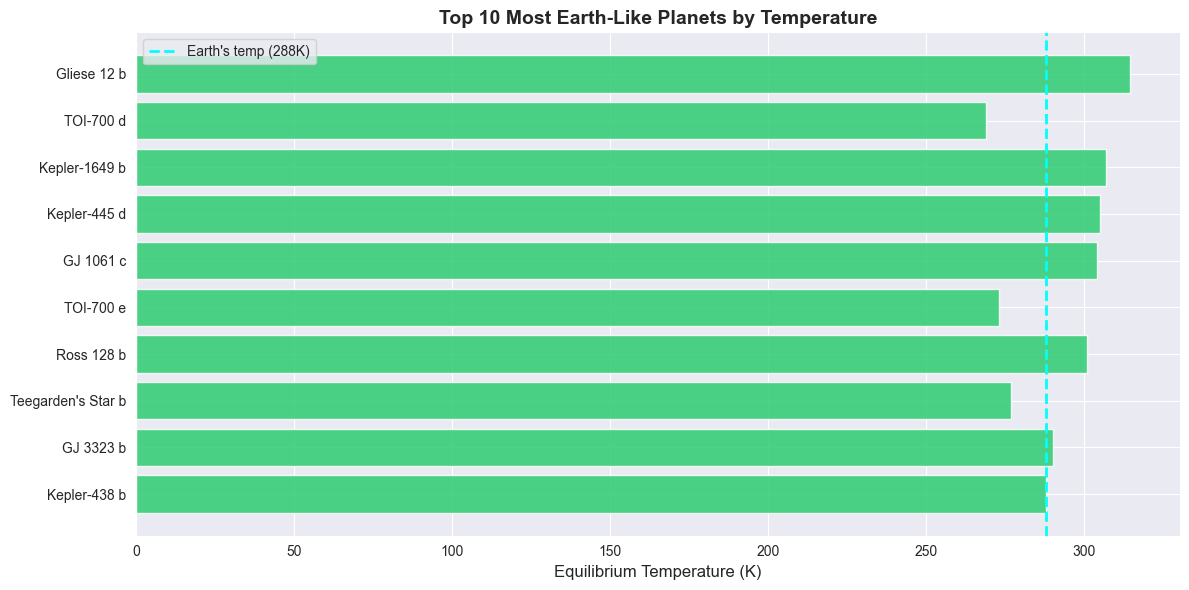

Chart 4 saved ✅


In [6]:
# Filter Earth-like planets (radius 0.8-1.25, temp 200-320K)
earthlike = df[
    (df['planet_radius_earth'] >= 0.8) & 
    (df['planet_radius_earth'] <= 1.25) &
    (df['equilibrium_temp_k'] >= 200) & 
    (df['equilibrium_temp_k'] <= 320)
].copy()

print(f"Total Earth-like planets in habitable zone: {len(earthlike)}")

# Sort by closest to Earth temp (288K)
earthlike['temp_diff'] = abs(earthlike['equilibrium_temp_k'] - 288)
top10 = earthlike.sort_values('temp_diff').head(10)

# Plot
plt.figure(figsize=(12, 6))
bars = plt.barh(top10['planet_name'], top10['equilibrium_temp_k'], 
                color='#2ecc71', edgecolor='white', alpha=0.85)

plt.axvline(x=288, color='cyan', linestyle='--', linewidth=2, label="Earth's temp (288K)")
plt.xlabel('Equilibrium Temperature (K)', fontsize=12)
plt.title('Top 10 Most Earth-Like Planets by Temperature', fontsize=14, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.savefig('chart4_top10_earthlike.png', dpi=150)
plt.show()
print("Chart 4 saved ✅")